In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn.functional as F

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Acceleration? {device}")

Acceleration? cuda


In [17]:
import pandas as pd

# Assuming your uploaded file is named 'your_large_data.csv'
# If you used files.upload(), the file will be in the current directory
# You might need to adjust the file path if it's in a subfolder
file_path = 'games_detailed_info2025.csv'

try:
    df = pd.read_csv(file_path)
    print(f"DataFrame loaded successfully from {file_path}. Here are the first few rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please ensure it's uploaded to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading the CSV file: {e}")

DataFrame loaded successfully from games_detailed_info2025.csv. Here are the first few rows:


,id,name,description,boardgamecategory,boardgamemechanic,boardgamedesigner,usersrated,rating,bayes_rating,num_comments,playtime,min_playtime,max_playtime
0,13,CATAN,"In CATAN (formerly The Settlers of Catan), pla...","['Economic', 'Negotiation']","['Chaining', 'Dice Rolling', 'Hexagon Grid', '...",['Klaus Teuber'],132477,7.09526,6.91526,22600,120,60,120
1,822,Carcassonne,Carcassonne is a tile placement game in which ...,"['Medieval', 'Territory Building']","['Area Majority / Influence', 'Enclosure', 'Ma...",['Klaus-Jürgen Wrede'],131182,7.41145,7.29556,22150,45,30,45
2,30549,Pandemic,"In Pandemic, several virulent diseases have br...",['Medical'],"['Action Points', 'Cooperative Game', 'Hand Ma...",['Matt Leacock'],128935,7.52913,7.42156,19897,45,45,45
3,68448,7 Wonders,You are the leader of one of the 7 great citie...,"['Ancient', 'Card Game', 'City Building', 'Civ...","['Closed Drafting', 'Hand Management', 'Neighb...",['Antoine Bauza'],107506,7.67463,7.56393,16690,30,30,30
4,167791,Terraforming Mars,"In the 2400s, mankind begins to terraform the ...","['Economic', 'Environmental', 'Industry / Manu...","['Closed Drafting', 'Contracts', 'End Game Bon...",['Jacob Fryxelius'],103923,8.35266,8.20450,14696,120,120,120


### Data Preprocessing for Tabular Data

This section preprocesses the `csv_data` to make it suitable for a neural network. It handles categorical features by one-hot encoding and scales numerical features. The `average` column is set as the target variable.

In [19]:
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.model_selection import train_test_split

# Drop columns that are not directly usable as features or have high cardinality
columns_to_drop = ['id', 'name', 'description', 'boardgamedesigner']
df_processed = df.drop(columns=columns_to_drop, errors='ignore')

# Handle 'boardgamecategory' and 'boardgamemechanic' (list-like strings)
def parse_list_string(s):
    if isinstance(s, str):
        try:
            # Evaluate string as a Python list and handle potential single quotes
            return eval(s.replace("'", '"'))
        except (SyntaxError, TypeError):
            return []
    return []

df_processed['boardgamecategory_list'] = df_processed['boardgamecategory'].apply(parse_list_string)
df_processed['boardgamemechanic_list'] = df_processed['boardgamemechanic'].apply(parse_list_string)

# Use MultiLabelBinarizer for one-hot encoding of these list-like columns
mlb_category = MultiLabelBinarizer()
category_features = mlb_category.fit_transform(df_processed['boardgamecategory_list'])
category_df = pd.DataFrame(category_features, columns=[f'category_{c}' for c in mlb_category.classes_], index=df_processed.index)

mlb_mechanic = MultiLabelBinarizer()
mechanic_features = mlb_mechanic.fit_transform(df_processed['boardgamemechanic_list'])
mechanic_df = pd.DataFrame(mechanic_features, columns=[f'mechanic_{m}' for m in mlb_mechanic.classes_], index=df_processed.index)

# Drop original list-like columns and add one-hot encoded ones
df_processed = df_processed.drop(columns=['boardgamecategory', 'boardgamemechanic', 'boardgamecategory_list', 'boardgamemechanic_list'], errors='ignore')
df_processed = pd.concat([df_processed, category_df, mechanic_df], axis=1)

# Separate features (X) and target (y)
X = df_processed.drop(columns=['rating'])
y = df_processed['rating']

# Handle missing numerical values (fill with mean)
numerical_cols = X.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())

# Scale numerical features
scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

# Convert to PyTorch tensors
X_tensor = torch.tensor(X.values, dtype=torch.float32)
y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1) # unsqueeze for regression output

# Determine input features for the model
input_features = X_tensor.shape[1]

print(f"Number of input features: {input_features}")
print(f"Shape of X_tensor: {X_tensor.shape}")
print(f"Shape of y_tensor: {y_tensor.shape}")

Number of input features: 280
Shape of X_tensor: torch.Size([27780, 280])
Shape of y_tensor: torch.Size([27780, 1])


In [43]:
# Summary of Features Used and Dropped

print("--- Feature Engineering Summary ---")

# 1. Dropped Columns
print(f"\nColumns Dropped (high cardinality or metadata):")
print(columns_to_drop)

# 2. Used Features
print(f"\nTotal Input Features: {input_features}")

# Break down used features
numerical_features = numerical_cols.tolist()
category_list = [c for c in X.columns if c.startswith('category_')]
mechanic_list = [m for m in X.columns if m.startswith('mechanic_')]

print(f"- Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"- One-Hot Categories ({len(category_list)}): {category_list[:5]}... (and {len(category_list)-5} more)")
print(f"- One-Hot Mechanics ({len(mechanic_list)}): {mechanic_list[:5]}... (and {len(mechanic_list)-5} more)")

--- Feature Engineering Summary ---

Columns Dropped (high cardinality or metadata):
['id', 'name', 'description', 'boardgamedesigner']

Total Input Features: 280
- Numerical Features (280): ['usersrated', 'bayes_rating', 'num_comments', 'playtime', 'min_playtime', 'max_playtime', 'category_Abstract Strategy', 'category_Action / Dexterity', 'category_Adventure', 'category_Age of Reason', 'category_American Civil War', 'category_American Indian Wars', 'category_American Revolutionary War', 'category_American West', 'category_Ancient', 'category_Animals', 'category_Arabian', 'category_Aviation / Flight', 'category_Bluffing', 'category_Book', 'category_Card Game', 'category_City Building', 'category_Civil War', 'category_Civilization', 'category_Collectible Components', 'category_Comic Book / Strip', 'category_Deduction', 'category_Dice', 'category_Economic', 'category_Educational', 'category_Electronic', 'category_Environmental', 'category_Expansion for Base-game', 'category_Exploration'

In [20]:
from torch.utils.data import DataLoader, TensorDataset

# Create a TensorDataset from the preprocessed tensors
full_dataset = TensorDataset(X_tensor, y_tensor)

# Define split sizes
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
validation_size = int(0.1 * total_size)
test_size = total_size - train_size - validation_size

# Ensure non-negative sizes in case of small datasets
train_size = max(0, train_size)
validation_size = max(0, validation_size)
test_size = max(0, total_size - train_size - validation_size)

# Handle the case where total_size is very small and splits might be 0
# Distribute remaining samples if any exist due to rounding
if train_size + validation_size + test_size < total_size:
    train_size += (total_size - (train_size + validation_size + test_size))

# Split the dataset into training, validation, and test sets
train_dataset, validation_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, validation_size, test_size]
)

# Create DataLoader instances for each split
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [37]:
class BaselineNet(nn.Module):
    def __init__(self, input_features, dropout_rate=0.3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_features, 512),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_rate),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.model(x)

In [22]:
def train_one_epoch(model, loader, loss_fn, optimizer, device):
    model.train()

    running_loss, total = 0, 0

    for X_batch, y_batch in loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        predictions = model(X_batch)
        loss = loss_fn(predictions, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)
        total += y_batch.size(0)

    return running_loss / total

In [23]:
def evaluate(model, loader, loss_fn, device):
    model.eval()
    running_loss, total = 0, 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            predictions = model(X_batch)
            loss = loss_fn(predictions, y_batch)

            running_loss += loss.item() * X_batch.size(0)
            total += y_batch.size(0)

    return running_loss / total

In [46]:
import copy

def fit(model, train_loader, val_loader, loss_fn, optimizer, device, epochs=10, patience=5):
    history = {
        "train_loss": [],
        "val_loss": []
    }

    model.to(device)
    best_val_loss = float('inf')
    best_model_wts = copy.deepcopy(model.state_dict())
    early_stop_count = 0

    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
        val_loss = evaluate(model, val_loader, loss_fn, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        print(f'Epoch: {epoch + 1}: Train loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            early_stop_count = 0
        else:
            early_stop_count += 1
            if early_stop_count >= patience:
                print(f"Early stopping triggered after {epoch + 1} epochs.")
                break

    # Load best model weights before returning
    model.load_state_dict(best_model_wts)
    return history

In [47]:
import matplotlib.pyplot as plt

def plot_history(history):
    epochs = range(1, len(history['train_loss']) + 1)

    plt.plot(epochs, history['train_loss'], label = 'Train Loss')
    plt.plot(epochs, history['val_loss'], label = 'Val Loss')
    plt.legend()
    plt.title('Loss curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.show()

Epoch: 1: Train loss: 0.6430, Val Loss: 0.2598
Epoch: 2: Train loss: 0.3369, Val Loss: 0.2417
Epoch: 3: Train loss: 0.3120, Val Loss: 0.2379
Epoch: 4: Train loss: 0.3022, Val Loss: 0.2361
Epoch: 5: Train loss: 0.2884, Val Loss: 0.2350
Epoch: 6: Train loss: 0.2772, Val Loss: 0.2264
Epoch: 7: Train loss: 0.2723, Val Loss: 0.2231
Epoch: 8: Train loss: 0.2625, Val Loss: 0.2266
Epoch: 9: Train loss: 0.2619, Val Loss: 0.2376
Epoch: 10: Train loss: 0.2541, Val Loss: 0.2119
Epoch: 11: Train loss: 0.2466, Val Loss: 0.2250
Epoch: 12: Train loss: 0.2449, Val Loss: 0.2319
Epoch: 13: Train loss: 0.2414, Val Loss: 0.2039
Epoch: 14: Train loss: 0.2369, Val Loss: 0.2083
Epoch: 15: Train loss: 0.2355, Val Loss: 0.2181
Epoch: 16: Train loss: 0.2304, Val Loss: 0.2028
Epoch: 17: Train loss: 0.2268, Val Loss: 0.1987
Epoch: 18: Train loss: 0.2230, Val Loss: 0.2055
Epoch: 19: Train loss: 0.2209, Val Loss: 0.1945
Epoch: 20: Train loss: 0.2135, Val Loss: 0.1995
Epoch: 21: Train loss: 0.2132, Val Loss: 0.1926
E

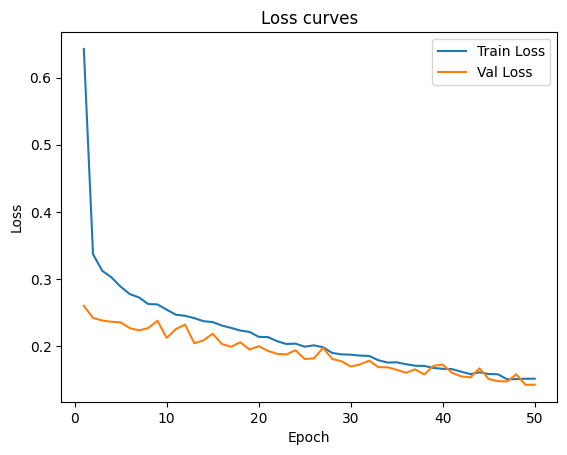

In [48]:
# Re-initialize model with Dropout (default 0.3)
model = BaselineNet(input_features=input_features, dropout_rate=0.3)

# Using HuberLoss instead of MSELoss to be more robust to outliers
loss_fn = nn.HuberLoss(delta=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Retrain the model with Huber Loss
history = fit(model, train_loader, validation_loader, loss_fn, optimizer, device, epochs=50)

plot_history(history)

In [49]:
model.eval()
num_predictions = 5

print(f"\nMaking {num_predictions} one-off predictions from the test set:")
for i in range(num_predictions):
    # Get a sample from the test_dataset
    sample_input, sample_target = test_dataset[i]

    # Move to the correct device and make a prediction
    sample_input = sample_input.unsqueeze(0).to(device) # Add batch dimension
    with torch.no_grad():
        prediction = model(sample_input)

    # Print the true value and the predicted value
    print(f"Sample {i+1}: True rating = {sample_target.item():.2f}, Predicted rating = {prediction.item():.2f}")


Making 5 one-off predictions from the test set:
Sample 1: True rating = 7.65, Predicted rating = 7.91
Sample 2: True rating = 6.48, Predicted rating = 6.14
Sample 3: True rating = 7.12, Predicted rating = 6.99
Sample 4: True rating = 4.14, Predicted rating = 4.76
Sample 5: True rating = 7.66, Predicted rating = 7.53


In [50]:
def predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, categories_list, mechanics_list, original_numerical_means, feature_columns_names, device):
    model.eval()

    # Create a Series with all columns from X, initialized with float 0.0 to ensure float dtype
    sample_series = pd.Series(0.0, index=feature_columns_names)

    # Fill numerical columns with mean values from the training data
    # original_numerical_means is a Series whose index are the numerical column names
    for col in original_numerical_means.index:
        if col in sample_series.index:
            sample_series[col] = original_numerical_means[col]

    # Transform the input categories list using the fitted mlb_category
    categories_transformed = mlb_category.transform([categories_list])
    categories_cols = mlb_category.classes_

    # Update the sample_series with the transformed categories (1.0 for present, 0.0 for absent)
    for i, col_val in enumerate(categories_transformed[0]):
        if col_val == 1 and f'category_{categories_cols[i]}' in sample_series.index:
            sample_series[f'category_{categories_cols[i]}'] = 1.0

    # Transform the input mechanics list using the fitted mlb_mechanic
    mechanics_transformed = mlb_mechanic.transform([mechanics_list])
    mechanics_cols = mlb_mechanic.classes_

    # Update the sample_series with the transformed mechanics (1.0 for present, 0.0 for absent)
    for i, col_val in enumerate(mechanics_transformed[0]):
        if col_val == 1 and f'mechanic_{mechanics_cols[i]}' in sample_series.index:
            sample_series[f'mechanic_{mechanics_cols[i]}'] = 1.0

    # Convert the Series to a DataFrame
    sample_df = pd.DataFrame([sample_series])

    # Select only the numerical columns for scaling
    # The numerical columns for scaling are the index of original_numerical_means
    numerical_cols_for_scaling = original_numerical_means.index
    sample_df[numerical_cols_for_scaling] = scaler.transform(sample_df[numerical_cols_for_scaling])

    # Convert to PyTorch tensor
    sample_tensor = torch.tensor(sample_df.values, dtype=torch.float32).to(device)

    with torch.no_grad():
        prediction = model(sample_tensor)

    return prediction.item()


In [51]:
# Get the list of numerical columns that exist in the original X dataframe
numerical_cols_in_x_train = X.select_dtypes(include=np.number).columns

# Calculate mean of numerical columns from the original (unscaled) X for filling defaults
X_numerical_original = df_processed[numerical_cols_in_x_train].copy()
original_numerical_means = X_numerical_original.mean()

# Example usage with sample categories and mechanics
sample_categories_1 = ['Economic', 'Negotiation']
sample_mechanics_1 = ['Dice Rolling', 'Hand Management', 'Set Collection']
predicted_rating_1 = predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, sample_categories_1, sample_mechanics_1, original_numerical_means, X.columns, device)
print(f"Predicted rating for categories {sample_categories_1} and mechanics {sample_mechanics_1}: {predicted_rating_1:.2f}")

sample_categories_2 = ['Medical']
sample_mechanics_2 = ['Cooperative Game', 'Area Majority / Influence', 'Variable Player Powers']
predicted_rating_2 = predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, sample_categories_2, sample_mechanics_2, original_numerical_means, X.columns, device)
print(f"Predicted rating for categories {sample_categories_2} and mechanics {sample_mechanics_2}: {predicted_rating_2:.2f}")

# Example with only mechanics, defaulting categories to their mean (empty list)
sample_mechanics_3 = ['Tile Placement', 'Pattern Building']
predicted_rating_3 = predict_with_mechanics(model, scaler, mlb_category, mlb_mechanic, [], sample_mechanics_3, original_numerical_means, X.columns, device)
print(f"Predicted rating for only mechanics {sample_mechanics_3}: {predicted_rating_3:.2f}")

Predicted rating for categories ['Economic', 'Negotiation'] and mechanics ['Dice Rolling', 'Hand Management', 'Set Collection']: 4.18
Predicted rating for categories ['Medical'] and mechanics ['Cooperative Game', 'Area Majority / Influence', 'Variable Player Powers']: 5.01
Predicted rating for only mechanics ['Tile Placement', 'Pattern Building']: 3.94


### Exploring impact of mechanics on predicted ratings for high-rated games

In [52]:
print("\n--- Analysis of High-Rated Games with Modified Mechanics ---")

# Helper function to parse list-like strings, similar to the one used in preprocessing
def parse_list_string_for_prediction(s):
    if isinstance(s, str):
        try:
            return eval(s.replace("'", '"'))
        except (SyntaxError, TypeError):
            return []
    return []

# Get top rated games from the original DataFrame for reference
top_rated_games = df.sort_values(by='rating', ascending=False).head(5)

print(f"\nTop 5 original games by rating:\n{top_rated_games[['name', 'rating']]}")

# Example 1: Gloomhaven (Highest rated in our sample)
game_name_1 = 'Gloomhaven'
game_data_1 = df[df['name'] == game_name_1].iloc[0]
original_categories_1 = parse_list_string_for_prediction(game_data_1['boardgamecategory'])
original_mechanics_1 = parse_list_string_for_prediction(game_data_1['boardgamemechanic'])

predicted_original_1 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_1, original_mechanics_1,
    original_numerical_means, X.columns, device
)

# Modify: Remove 'Storytelling' mechanic
modified_mechanics_1 = [m for m in original_mechanics_1 if m != 'Storytelling']
predicted_modified_1 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_1, modified_mechanics_1,
    original_numerical_means, X.columns, device
)

print(f"\nGame: {game_name_1} (Original Rating: {game_data_1['rating']:.2f})")
print(f"  Original Prediction: {predicted_original_1:.2f} (Mechanics: {original_mechanics_1})")
print(f"  Modified Prediction: {predicted_modified_1:.2f} (Mechanics: {modified_mechanics_1}) (Removed 'Storytelling')")

# Example 2: Brass: Birmingham
game_name_2 = 'Brass: Birmingham'
game_data_2 = df[df['name'] == game_name_2].iloc[0]
original_categories_2 = parse_list_string_for_prediction(game_data_2['boardgamecategory'])
original_mechanics_2 = parse_list_string_for_prediction(game_data_2['boardgamemechanic'])

predicted_original_2 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_2, original_mechanics_2,
    original_numerical_means, X.columns, device
)

# Modify: Add 'Dice Rolling' mechanic
modified_mechanics_2 = original_mechanics_2 + ['Dice Rolling']
predicted_modified_2 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_2, modified_mechanics_2,
    original_numerical_means, X.columns, device
)

print(f"\nGame: {game_name_2} (Original Rating: {game_data_2['rating']:.2f})")
print(f"  Original Prediction: {predicted_original_2:.2f} (Mechanics: {original_mechanics_2})")
print(f"  Modified Prediction: {predicted_modified_2:.2f} (Mechanics: {modified_mechanics_2}) (Added 'Dice Rolling')")

# Example 3: Ark Nova
game_name_3 = 'Ark Nova'
game_data_3 = df[df['name'] == game_name_3].iloc[0]
original_categories_3 = parse_list_string_for_prediction(game_data_3['boardgamecategory'])
original_mechanics_3 = parse_list_string_for_prediction(game_data_3['boardgamemechanic'])

predicted_original_3 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_3, original_mechanics_3,
    original_numerical_means, X.columns, device
)

# Modify: Remove 'Hexagon Grid' mechanic
modified_mechanics_3 = [m for m in original_mechanics_3 if m != 'Hexagon Grid']
predicted_modified_3 = predict_with_mechanics(
    model, scaler, mlb_category, mlb_mechanic,
    original_categories_3, modified_mechanics_3,
    original_numerical_means, X.columns, device
)

print(f"\nGame: {game_name_3} (Original Rating: {game_data_3['rating']:.2f})")
print(f"  Original Prediction: {predicted_original_3:.2f} (Mechanics: {original_mechanics_3})")
print(f"  Modified Prediction: {predicted_modified_3:.2f} (Mechanics: {modified_mechanics_3}) (Removed 'Hexagon Grid')")


--- Analysis of High-Rated Games with Modified Mechanics ---

Top 5 original games by rating:
                                                  name   rating
27168                             Aprendices de Druida  9.83871
27490                                    Match'n Lock!  9.68333
15746                            The Cones of Dunshire  9.55918
23070  Shadows of Brimstone: The Impossible Hell Train  9.49333
23193                               Eldfall Chronicles  9.46444

Game: Gloomhaven (Original Rating: 8.57)
  Original Prediction: 7.02 (Mechanics: ['Action Queue', 'Action Retrieval', 'Campaign / Battle Card Driven', 'Card Play Conflict Resolution', 'Communication Limits', 'Cooperative Game', 'Critical Hits and Failures', 'Deck Construction', 'Grid Movement', 'Hand Management', 'Hexagon Grid', 'Legacy Game', 'Line of Sight', 'Modular Board', 'Multi-Use Cards', 'Narrative Choice / Paragraph', 'Once-Per-Game Abilities', 'Role Playing', 'Scenario / Mission / Campaign Game', 'Simulta